Human In Loop

In [1]:
from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3-32b")


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from typing import Annotated

class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
from langchain_tavily  import TavilySearch
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.types import Command,interrupt
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()
graph_builder=StateGraph(State)

@tool
def human_response(query:str)->str:
    """ request for human assistence and guidence"""
    human_response=interrupt({"query":query})
    return human_response["data"]

tool=TavilySearch(max_results=2)

tools=[tool,human_response]

llm_with_tool=llm.bind_tools(tools)



In [4]:
def chatbot(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

In [5]:
graph_builder.add_node("chatbot",chatbot)
toolnode=ToolNode(tools=tools)
graph_builder.add_node("tools",toolnode)

graph_builder.add_edge(START,"chatbot")
graph_builder.add_conditional_edges("chatbot",tools_condition)

graph_builder.add_edge("tools","chatbot")
graph=graph_builder.compile(checkpointer=memory)



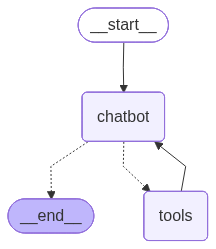

In [6]:
from IPython.display import Image,display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [9]:
user_input="i need to some guidenece and human assistent for building AI Agents"
config={"configurable":{"thread_id":"1"}}

events=graph.stream({"messages":user_input},config=config,stream_mode="values")
for event in events:
    event["messages"][-1].pretty_print()


================================ Human Message =================================

i need to some guidenece and human assistent for building AI Agents
================================== Ai Message ==================================
Tool Calls:
  human_response (vrb541p77)
 Call ID: vrb541p77
  Args:
    query: I need guidance and human assistance for building AI Agents
================================== Ai Message ==================================
Tool Calls:
  human_response (vrb541p77)
 Call ID: vrb541p77
  Args:
    query: I need guidance and human assistance for building AI Agents


In [ ]:
human_response=("we are here to provide assistence please go throuh langchain official documnetion it is very helpfull to build ai agent")
command=Command(resume={"data":human_response})
events=graph.stream({"messages":human_response},config=config,stream_mode="values")
for event in events:
    event["messages"][-1].pretty_print()



================================ Human Message =================================

i need to some guidenece and human assistent for building AI Agents
================================== Ai Message ==================================
Tool Calls:
  human_response (gn0x05rzk)
 Call ID: gn0x05rzk
  Args:
    query: I need guidance and human assistance for building AI Agents
================================== Ai Message ==================================
Tool Calls:
  human_response (gn0x05rzk)
 Call ID: gn0x05rzk
  Args:
    query: I need guidance and human assistance for building AI Agents
